# 15. Thermal Interiors

A layer's temperature sets its viscosity and so its tidal response. The temperature in turn depends on how much heat the layer makes and how fast it loses it. Each `Layer` can carry two models for this: a cooling model (`Cooling`) that turns a temperature drop into a heat flux, and a radiogenics model (`Radiogenics`) that turns a mass and a time into a heating rate.

This notebook evaluates both models on their own, attaches them to the layers of the bundled Io, and solves the structure with temperature and heat flow. It then splits Io's tidal heating among its layers and ends with a heat budget that shows whether the interior warms or cools.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, M_jup, seconds_per_myr
from TidalPy.Cooling import make_cooling
from TidalPy.Radiogenics import make_radiogenics, available_isotope_datasets, IsotopeRadiogenics
from TidalPy.Structures.configs import build_world

# Io's orbit about Jupiter, used in the tidal sections
A_IO = 4.217e8                         # semi-major axis [m]
E_IO = 0.0041                          # forced eccentricity
N_IO = np.sqrt(G * M_jup / A_IO**3)    # mean motion [rad s-1]. Io rotates synchronously
SURFACE_TEMPERATURE = 110.0            # Io's mean surface temperature [K]
LAYER_COLORS = {"core": "tab:gray", "mantle": "tab:brown", "asthenosphere": "tab:orange"}

## Cooling Models

`make_cooling` builds a cooling model by name: `off`, `conduction`, or `convection`. Each model's `calc_cooling` takes eight inputs: the temperature drop across the layer \[K\], layer thickness \[m\], gravity \[m s$^{-2}$\], density \[kg m$^{-3}$\], viscosity \[Pa s\], thermal conductivity \[W m$^{-1}$ K$^{-1}$\], thermal diffusivity \[m$^2$ s$^{-1}$\], and thermal expansivity \[K$^{-1}$\]. It returns the heat flux \[W m$^{-2}$\], the thermal boundary-layer thickness \[m\], and the Rayleigh and Nusselt numbers.

The values below describe a silicate mantle approx. 900 km thick with a 1000 K temperature drop, similar to Io's mantle.

In [2]:
# Silicate mantle, with the thermal constants of TidalPy's mantle_rock defaults
delta_temp   = 1000.0                             # [K]
thickness    = 9.1e5                              # [m]
gravity      = 1.5                                # [m s-2]
density      = 3300.0                             # [kg m-3]
conductivity = 3.75                               # [W m-1 K-1]
expansivity  = 5.2e-5                             # [K-1]
diffusivity  = conductivity / (density * 1200.0)  # [m2 s-1], heat capacity of 1200 J kg-1 K-1
viscosity    = 1.0e20                             # [Pa s]

cooling_models = {name: make_cooling(name) for name in ("off", "conduction", "convection")}
print(f"{'model':<11} {'flux [W/m2]':>12} {'boundary layer [km]':>20} {'Ra':>10} {'Nu':>7}")
for name, model in cooling_models.items():
    result = model.calc_cooling(
        delta_temp, thickness, gravity, density, viscosity, conductivity, diffusivity, expansivity)
    print(f"{model.model_name:<11} {result.cooling_flux:12.4f} {result.boundary_layer_thickness / 1e3:20.1f} "
          f"{result.rayleigh:10.3e} {result.nusselt:7.2f}")

model        flux [W/m2]  boundary layer [km]         Ra      Nu
off               0.0000                455.0  0.000e+00    1.00
conduction        0.0041                910.0  0.000e+00    1.00
convection        0.0507                 74.0  2.048e+06   12.30


The `off` model moves no heat. Conduction carries $k \Delta T / d$ across the whole layer. Convection thins the conducting region to a boundary layer of thickness $d / \mathrm{Nu}$, so it carries $\mathrm{Nu}$ times the conductive flux.

## Conduction to Convection Transition

The Rayleigh number $\mathrm{Ra} = \alpha \rho g \Delta T d^3 / (\eta \kappa)$ compares the buoyancy that drives a hot parcel upward with the viscous and diffusive losses that resist it. The convection model uses $\mathrm{Nu} = (\mathrm{Ra} / \mathrm{Ra}_\mathrm{crit})^{1/3}$ with $\mathrm{Ra}_\mathrm{crit} = 1100$ by default, and never lets the Nusselt number fall below 2. The sweep below varies only the viscosity, using `calc_cooling_vectorize_viscosity` to evaluate it in one call.

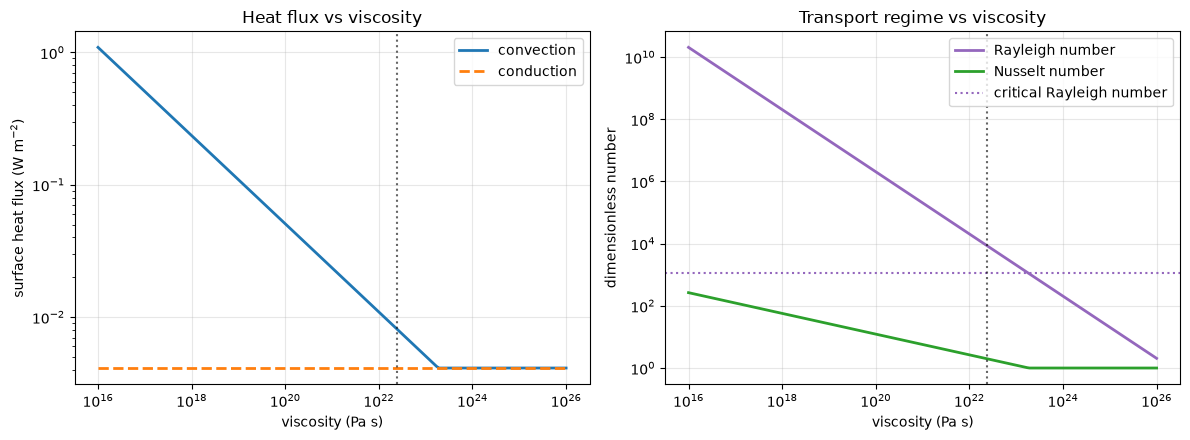

Ra falls to the critical value at a viscosity of 1.93e+23 Pa s
Nu reaches its floor of 2 at a viscosity of      2.41e+22 Pa s (dotted line)
flux ratio convection / conduction at 1e18 Pa s: 56.7


In [3]:
viscosities = np.logspace(16.0, 26.0, 200)   # [Pa s]

sweeps = {}
for name in ("conduction", "convection"):
    # Only the viscosity varies
    sweeps[name] = cooling_models[name].calc_cooling_vectorize_viscosity(
        delta_temp, thickness, gravity, density, viscosities, conductivity, diffusivity, expansivity)

convection = sweeps["convection"]
critical_viscosity = viscosities[np.argmin(np.abs(convection.rayleigh - 1100.0))]
floor_viscosity = viscosities[np.argmax(convection.nusselt <= 2.0)]

fig, (ax_flux, ax_numbers) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_flux.loglog(viscosities, convection.cooling_flux, lw=2, label="convection")
ax_flux.loglog(viscosities, sweeps["conduction"].cooling_flux, lw=2, ls="--", label="conduction")
ax_flux.set_ylabel("surface heat flux (W m$^{-2}$)")
ax_flux.set_title("Heat flux vs viscosity")

ax_numbers.loglog(viscosities, convection.rayleigh, lw=2, color="tab:purple", label="Rayleigh number")
ax_numbers.loglog(viscosities, convection.nusselt, lw=2, color="tab:green", label="Nusselt number")
ax_numbers.axhline(1100.0, color="tab:purple", ls=":", label="critical Rayleigh number")
ax_numbers.set_ylabel("dimensionless number")
ax_numbers.set_title("Transport regime vs viscosity")

for ax in (ax_flux, ax_numbers):
    ax.axvline(floor_viscosity, color="k", ls=":", alpha=0.6)
    ax.set_xlabel("viscosity (Pa s)")
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Ra falls to the critical value at a viscosity of {critical_viscosity:.2e} Pa s")
print(f"Nu reaches its floor of 2 at a viscosity of      {floor_viscosity:.2e} Pa s (dotted line)")
print(f"flux ratio convection / conduction at 1e18 Pa s: "
      f"{convection.cooling_flux[np.argmin(np.abs(viscosities - 1e18))] / sweeps['conduction'].cooling_flux[0]:.1f}")

At viscosities below the dotted line, the convective flux falls as $\eta^{-1/3}$ and is between 2 and about 260 times the conductive flux. Above it, the Nusselt floor holds the convective flux at twice the conductive value, even past the critical Rayleigh number where a real layer stops convecting. The convection model does not switch to conduction by itself. For a layer whose Rayleigh number stays subcritical, attach the `conduction` model instead.

## Radiogenic Heating Models

`make_radiogenics` builds a radiogenics model by name: `off`, `isotope`, or `fixed`. `calc_heating(time, mass)` returns the heating \[W\] of a mass \[kg\] at a time \[s\]. With a mass of 1 kg it gives the specific heating rate \[W kg$^{-1}$\]. The isotope model sums the decay of a list of isotopes, and `available_isotope_datasets` lists the built-in literature sets. The fixed model applies one lumped rate with an optional single half-life.

Each model has a reference time. The two present-day datasets quote abundances at 4600 Myr after the formation of the Solar System, so $t = 0$ is formation and $t = 4600$ Myr is today. The `llri_and_slri` set adds the short-lived isotopes and is referenced to formation instead.

built-in isotope datasets: ['modern_day_chondritic', 'llri', 'slri', 'llri_and_slri', 'bulk_silicate_earth']
modern_day_chondritic    at formation: 4.556e-11 W/kg   today: 5.173e-12 W/kg
bulk_silicate_earth      at formation: 2.487e-11 W/kg   today: 4.965e-12 W/kg
fixed, 2 Gyr half-life   at formation: 2.462e-11 W/kg   today: 5.000e-12 W/kg


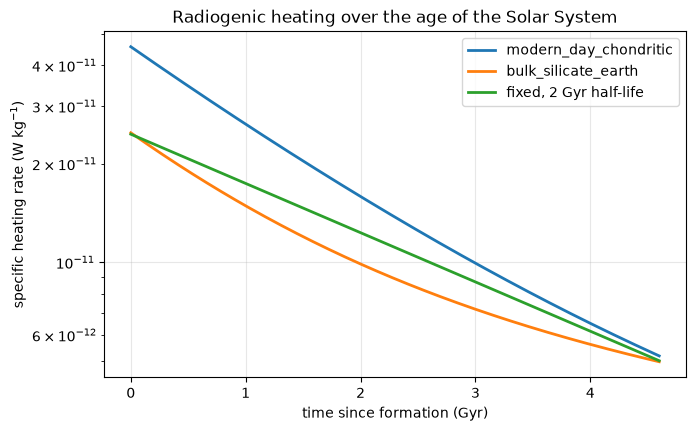

In [4]:
print("built-in isotope datasets:", available_isotope_datasets())

present_day = 4600.0 * seconds_per_myr   # [s] after formation
radiogenic_models = {
    "modern_day_chondritic": IsotopeRadiogenics.from_dataset("modern_day_chondritic"),
    "bulk_silicate_earth": make_radiogenics(
        "isotope",
        {"isotopes": "bulk_silicate_earth"}),                # same model type, built by name
    "fixed, 2 Gyr half-life": make_radiogenics(
        "fixed",
        {"fixed_heat_production_w_kg": 5.0e-12,             # rate at the reference time [W kg-1]
         "average_half_life_s": 2000.0 * seconds_per_myr,   # one effective half-life [s]
         "ref_time_s": present_day}),                       # the rate is quoted for today
}

times = np.linspace(0.0, present_day, 300)   # [s] from formation to today
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for label, model in radiogenic_models.items():
    # Heating of 1 kg, i.e., the specific rate [W kg-1]
    specific_heating = model.calc_heating_vectorize_time(times, 1.0)
    ax.semilogy(times / seconds_per_myr / 1.0e3, specific_heating, lw=2, label=label)
    print(f"{label:<24} at formation: {specific_heating[0]:.3e} W/kg   today: {specific_heating[-1]:.3e} W/kg")
ax.set_xlabel("time since formation (Gyr)")
ax.set_ylabel("specific heating rate (W kg$^{-1}$)")
ax.set_title("Radiogenic heating over the age of the Solar System")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The chondritic set starts higher because it has more potassium, whose $^{40}$K decays with a 1.25 Gyr half-life. Uranium and thorium dominate the bulk silicate Earth set, so its rate falls more slowly.

## Cooling and Radiogenics on a World's Layers

The bundled Io has an iron core, a solid silicate mantle, and a 100 km thick, melt-weakened asthenosphere. Its file gives the two silicate layers the convection model and the chondritic isotopes, and every layer `use_heating = True`, which lets the world's heat sources (radiogenic, and tidal once `calc_tides` has run) warm it in a thermal solve. The core has neither model: a layer without a cooling model holds one temperature (a perfect conductor).

A layer's `cooling` property takes a model, a model name, or a config table, and `set_radiogenics` attaches a radiogenics model. Here the core is given conduction, and the asthenosphere the bulk silicate Earth abundances.

In [5]:
io_thermal = build_world("io")

for layer in io_thermal:
    cooling = layer.cooling.model_name if layer.cooling_set else "none"
    radiogenics = layer.get_config_dict().get("radiogenics", {}).get("model", "none")
    print(f"{layer.name:<14} cooling: {cooling:<11} radiogenics: {radiogenics:<8} "
          f"use_heating: {layer.use_heating!s:<6} temperature: {layer.temperature:.0f} K")

io_thermal.core.cooling = make_cooling("conduction")          # the core conducts instead of holding one temperature
io_thermal.asthenosphere.set_radiogenics(
    IsotopeRadiogenics.from_dataset("bulk_silicate_earth"))   # replaces the chondritic abundances

print("core cooling is now:", io_thermal.core.cooling.model_name)
asthenosphere_isotopes = io_thermal.asthenosphere.get_config_dict()["radiogenics"]
print("asthenosphere element concentrations are now:",
      dict(zip(asthenosphere_isotopes["isotope_names"], asthenosphere_isotopes["concentrations"])))

core           cooling: none        radiogenics: none     use_heating: True   temperature: 1900 K
mantle         cooling: convection  radiogenics: isotope  use_heating: True   temperature: 1600 K
asthenosphere  cooling: convection  radiogenics: isotope  use_heating: True   temperature: 1600 K
core cooling is now: conduction
asthenosphere element concentrations are now: {'U238': 2.03e-08, 'U235': 2.03e-08, 'Th232': 7.95e-08, 'K40': 0.00024}


## Temperature and Heat Flow Profile

`solve_eos` integrates gravity, pressure, mass, and moment of inertia from the center to the surface. With `solve_temperature=True` it also integrates the temperature and the outward heat flow $L(r)$ \[W\]. Each layer's `temperature` is an input, and the profile is built around it according to the layer's cooling model:

- No cooling model (or `off`): The layer is isothermal.
- `conduction`: The layer conducts, and its temperature applies at the mid-radius.
- `convection`: An adiabatic interior, $dT/dr = -\alpha g T / c_p$, between conducting boundary layers at the base and top whose thickness comes from the Nusselt scaling. The layer's temperature applies at the top of the adiabatic interior (the upper-mantle temperature of parameterized convection), and the adiabat warms downward from it.

The layers form a chain of thermal resistances, and the heat flow through each interface follows from the temperature difference across it. `surface_temperature` is the temperature the outermost layer loses heat to. A heated layer (`use_heating`) adds $dL/dr = 4 \pi r^2 h$, where $h$ \[W m$^{-3}$\] is the heating of the world's heat sources there: radiogenic at the solve's `time` (each model's own reference time when `time` is omitted, today for the chondritic set), tidal once `calc_tides` has run (the heat budget below), and any prescribed heating.

The solve does not assume steady state. `layer_temperature_rate` \[K s$^{-1}$\] reports each layer's rate from $C \, dT/dt = L_\mathrm{in} - L_\mathrm{out} + H$, with $C$ \[J K$^{-1}$\] the heat the layer's solved profile stores per kelvin of its temperature (`layer_thermal_capacity`). The material's viscosity, and its melting where `use_melting` is on, use the local temperature at every radius; its density uses it only where `use_thermal_expansion` is on.

The bundled Io sets `solve_temperature = false` in its file, so the call passes it explicitly.

success: True   thermal passes: 5   converged: True


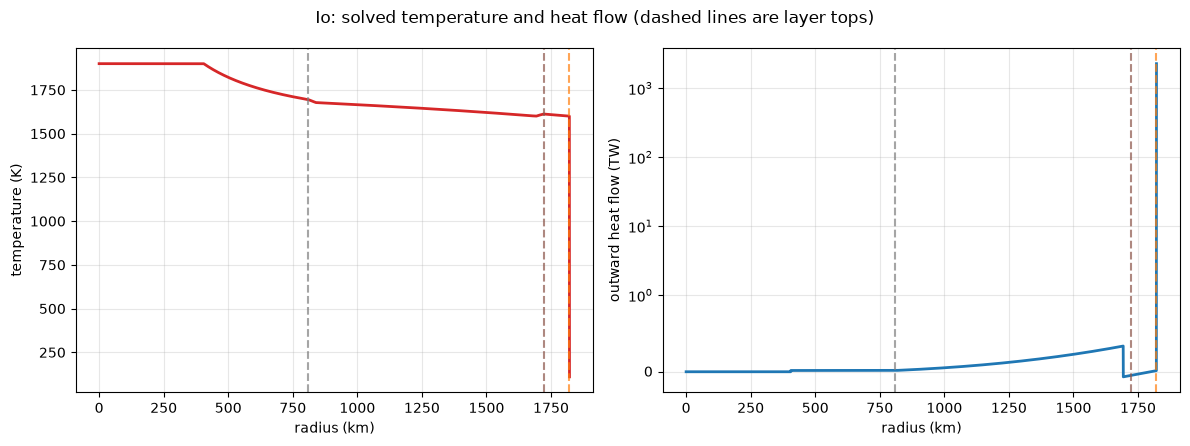

layer            T [K]  flow in [W]  flow out [W]     heating [W]  dT/dt [K/Myr]
core              1900    0.000e+00     1.662e+10       0.000e+00          -0.15
mantle            1600    1.662e+10    -4.823e+10       3.372e+11           0.16
asthenosphere     1600   -4.823e+10     2.268e+15       6.280e+10       -4701.41


In [6]:
thermal = io_thermal.solve_eos(
    solve_temperature=True,                      # carry temperature and heat flow through the structure
    surface_temperature=SURFACE_TEMPERATURE)     # the outermost layer loses heat to 110 K
print(f"success: {thermal['success']}   thermal passes: {thermal['thermal_passes']}   "
      f"converged: {thermal['thermal_converged']}")

radii = np.linspace(0.0, io_thermal.radius, 4000)   # [m]
temperature = io_thermal.get_temperature(radii)      # [K], read from the solved profile
heat_flow = io_thermal.get_heat_flow(radii)          # [W], outward through each sphere

fig, (ax_temp, ax_flow) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_temp.plot(radii / 1e3, temperature, lw=2, color="tab:red")
ax_temp.set_ylabel("temperature (K)")
ax_flow.plot(radii / 1e3, heat_flow / 1e12, lw=2, color="tab:blue")
ax_flow.set_ylabel("outward heat flow (TW)")
ax_flow.set_yscale("symlog", linthresh=1.0)
for ax in (ax_temp, ax_flow):
    for layer in io_thermal:
        ax.axvline(layer.radius_outer / 1e3, color=LAYER_COLORS[layer.name], ls="--", alpha=0.7)
    ax.set_xlabel("radius (km)")
    ax.grid(alpha=0.3)
fig.suptitle("Io: solved temperature and heat flow (dashed lines are layer tops)")
fig.tight_layout()
plt.show()

print(f"{'layer':<14} {'T [K]':>7} {'flow in [W]':>12} {'flow out [W]':>13} {'heating [W]':>15} "
      f"{'dT/dt [K/Myr]':>14}")
for i, layer in enumerate(io_thermal):
    print(f"{layer.name:<14} {thermal['layer_temperature'][i]:7.0f} {thermal['layer_heat_flow_in'][i]:12.3e} "
          f"{thermal['layer_heat_flow_out'][i]:13.3e} {thermal['layer_heating'][i]:15.3e} "
          f"{thermal['layer_temperature_rate'][i] * seconds_per_myr:14.2f}")

The core has no heat source. Its inner half carries no heat and stays at the 1900 K set at its mid-radius. Its outer half conducts down to about 1700 K at the core-mantle boundary and passes about $1.6 \times 10^{10}$ W into the mantle.

The mantle's 1600 K applies at the top of its adiabatic interior, and the adiabat warms downward to about 1685 K at its base. Its convection model uses the temperature drop across both boundary layers, including the one to the hotter core, to set the Rayleigh and Nusselt numbers and the boundary-layer thicknesses. The asthenosphere's adiabat likewise reaches about 1612 K at its base, warmer than the top of the mantle, so heat also flows down into the mantle from above (the negative heat flow). With both inflows and its own radiogenic heat, the mantle warms slowly.

The asthenosphere's low viscosity gives a Nusselt number in the hundreds and a top boundary layer about 100 m thick, so it loses about $2 \times 10^{15}$ W to the surface. The bundled Io has no conducting lithosphere, so this loss is larger than a model with a stagnant lid would give.

## Per-Layer Tidal Heating

`calc_tides` computes the world's total tidal heating and each layer's share. How it finds the share depends on the source of the Love numbers:

- `radial_solver` (default): Each layer's heating is the volume integral of the radial solution's heating density over that layer (the same integral `calc_3d_tides` does, summed over every axis). The layers therefore partition the total.
- `homogeneous`, `cpl`, `ctl`: Each tidal layer is treated as a homogeneous planet made of its own averaged material, with its Love numbers weighted by its `tidal_scale` (its volume fraction unless set). The world's Love number is the sum of these terms, and each layer takes the heating of its own term.

The tides use the fitted, fixed temperatures in the Io file, so this world is solved without the temperature profile.

Love method        total (W)           core         mantle  asthenosphere
radial_solver      9.330e+13      6.012e+08      3.813e+12      8.948e+13
homogeneous        1.370e+14      2.317e+08      3.964e+12      1.331e+14
tidal scales (homogeneous): [0.0879, 0.7562, 0.1558]


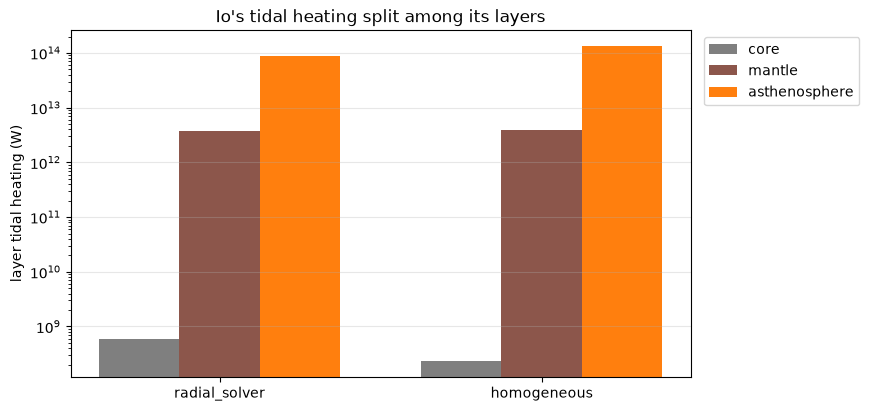

In [7]:
io_tides = build_world("io")
io_tides.solve_eos()   # the rheology tide model needs a solved interior

tidal_shares = {}
tidal_totals = {}
for method in ("radial_solver", "homogeneous"):
    io_tides.set_tide_config(love_method=method)
    io_tides.calc_tides(
        orbital_frequency=N_IO,   # [rad s-1]
        spin_frequency=N_IO,      # synchronous rotation
        eccentricity=E_IO,
        obliquity=0.0,
        semi_major_axis=A_IO,     # [m]
        host_mass=M_jup)          # [kg]
    tidal_shares[method] = np.array([io_tides.get_layer_tidal_heating(i) for i in range(len(io_tides))])
    tidal_totals[method] = io_tides.get_tidal_heating()
io_tides.set_tide_config(love_method="radial_solver")

print(f"{'Love method':<16}{'total (W)':>12}" + "".join(f"{layer.name:>15}" for layer in io_tides))
for method, shares in tidal_shares.items():
    print(f"{method:<16}{tidal_totals[method]:12.3e}" + "".join(f"{share:15.3e}" for share in shares))
print("tidal scales (homogeneous):", [round(io_tides.get_layer_tidal_scale(i), 4) for i in range(len(io_tides))])

fig, ax = plt.subplots(figsize=(8, 4.5))
bar_width = 0.25
positions = np.arange(len(tidal_shares))
for i, layer in enumerate(io_tides):
    ax.bar(positions + (i - 1) * bar_width, [shares[i] for shares in tidal_shares.values()],
           width=bar_width, color=LAYER_COLORS[layer.name], label=layer.name)
ax.set_xticks(positions, list(tidal_shares))
ax.set_yscale("log")
ax.set_ylabel("layer tidal heating (W)")
ax.set_title("Io's tidal heating split among its layers")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(alpha=0.3, axis="y")
plt.show()

With the radial solver, the asthenosphere takes 96 percent of Io's $9.3 \times 10^{13}$ W, the mantle 4 percent, and the core almost none. The homogeneous method weights each layer by its volume fraction (0.09, 0.76, and 0.16 here) and still puts 97 percent in the asthenosphere. A planet made of the asthenosphere's hot, soft material dissipates far more than one made of the mantle's. The homogeneous total, $1.4 \times 10^{14}$ W, is about 1.5 times the radial solver's. The quasi-homogeneous estimate is fast and ranks the layers the same way, but only the radial solver resolves how the layers deform together.

## Heat Budget

`calc_tides` also records each layer's tidal heating as the world's tidal heat source. `calc_layer_temperature_rate` combines it with the last thermal solve: each layer warms at $(C + C_\mathrm{latent})\,dT/dt = L_\mathrm{in} - L_\mathrm{out} + H$, where $H$ is its radiogenic heat and, in a layer with `use_heating`, its tidal heat. A step of a thermal evolution is therefore `solve_eos`, `calc_tides`, then the rates, and the next `solve_eos` carries the tidal heat through the heated layers' heat flow as well.

Here the tides are raised in the thermally solved Io, whose viscosities follow its solved temperatures rather than the fitted, fixed ones above.

In [8]:
# Tides of the thermally solved Io, which calc_tides also records as the world's tidal heat source
io_thermal.calc_tides(
    orbital_frequency=N_IO,   # [rad s-1]
    spin_frequency=N_IO,      # synchronous rotation
    eccentricity=E_IO,
    obliquity=0.0,
    semi_major_axis=A_IO,     # [m]
    host_mass=M_jup)          # [kg]
tidal_source = io_thermal.tidal_heat_source   # [W] by layer name

print(f"{'layer':<14} {'radiogenic [W]':>15} {'tidal [W]':>11} {'net flow in [W]':>16} {'dT/dt [K/Myr]':>14}")
for i, layer in enumerate(io_thermal):
    radiogenic = thermal["layer_heating_radiogenic"][i]
    net_flow_in = thermal["layer_heat_flow_in"][i] - thermal["layer_heat_flow_out"][i]
    # The last solve's heat flows and radiogenic heat, plus the tidal heat of a layer with use_heating
    warming_rate = io_thermal.calc_layer_temperature_rate(layer.name) * seconds_per_myr   # [K Myr-1]
    print(f"{layer.name:<14} {radiogenic:15.3e} {tidal_source.get(layer.name, 0.0):11.3e} {net_flow_in:16.3e} "
          f"{warming_rate:14.1f}")

radiogenic_total = io_thermal.calc_internal_heating(present_day)   # [W], summed over the layers
total_tidal = io_thermal.get_tidal_heating()                         # [W]
heat_loss = io_thermal.get_heat_flow(io_thermal.radius)              # [W], leaving through the surface
net_world = radiogenic_total + total_tidal - heat_loss
print()
print(f"radiogenic heating : {radiogenic_total:.3e} W")
print(f"tidal heating      : {total_tidal:.3e} W")
print(f"surface heat loss  : {heat_loss:.3e} W")
print(f"net                : {net_world:.3e} W, so Io would {'warm' if net_world > 0.0 else 'cool'}")

# The next solve carries the tidal heat through the heated layers' heat flow too
next_solve = io_thermal.solve_eos(
    solve_temperature=True,
    surface_temperature=SURFACE_TEMPERATURE)
print()
print("tidal heating in the next solve [W]:",
      {layer.name: f"{power:.3e}" for layer, power in zip(io_thermal, next_solve["layer_heating_tidal"])})

layer           radiogenic [W]   tidal [W]  net flow in [W]  dT/dt [K/Myr]
core                 0.000e+00   2.253e+08       -1.662e+10           -0.1
mantle               3.372e+11   4.605e+12        6.485e+10            2.0
asthenosphere        6.280e+10   1.007e+14       -2.268e+15        -4492.6

radiogenic heating : 4.000e+11 W
tidal heating      : 1.053e+14 W
surface heat loss  : 2.268e+15 W
net                : -2.162e+15 W, so Io would cool

tidal heating in the next solve [W]: {'core': '2.253e+08', 'mantle': '4.605e+12', 'asthenosphere': '1.007e+14'}


The thermally solved Io dissipates $1.06 \times 10^{14}$ W, 13 percent more than the fixed-temperature Io, because its mantle warms toward its base and softens. With tides, the mantle warms at about 2 K per Myr instead of 0.2.

The surface loss of the bundled Io, which has no conducting lithosphere, is about 22 times its radiogenic and tidal heating combined, so the asthenosphere cools quickly. A stagnant lid or a cooler asthenosphere would bring the budget closer to balance.